In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lake_ice_helpers import lake_files
from count_analysis_helpers import *
from count_network_library import *
import os
import torch
from torch import nn
from torch.utils.data import Dataset
from torchvision import datasets
from torchvision.transforms import ToTensor
import torch.optim as optim

In [ ]:
data_path = None #Add your path here
model_path = None
visualization_path = None
data_ip, ltbl_ice, ltbl_ice_depth, df_ice_clean_sorted = lake_files(data_path=data_path)

In [4]:
df_ice_clean_sorted = df_ice_clean_sorted.sort_values('year')
df_ice_clean_sorted = df_ice_clean_sorted.reset_index(drop=True)

In [5]:
df_ice_clean_sorted.head()

,station_id,year,ice_on,ice_off,ice_on_doy,ice_off_doy,ice_cover_duration,lake_id,country,lake_name,lat_wgs84,lon_wgs84,altitude_m,area_ha,depth_max_m,log_area_ha
0,4_1,1950,1949-12-10,1950-05-27,344.0,147.0,168.0,4,SE,Ajaure,65.510112,15.624015,439.0,1561.67,18.5,7.353511
1,15_3,1950,1949-12-30,1950-05-30,364.0,150.0,151.0,15,SE,Stor-Blåsjön Stora Blåsjön-Delen,64.796179,14.163889,448.7,928.54,72.0,6.833613
2,508_1,1950,1949-11-29,1950-06-08,333.0,159.0,191.0,508,SE,Stor-Laisan Stor-Laisan-Delen,65.739096,15.338325,454.0,1297.35,36.0,7.168079
3,511_1,1950,1950-01-07,1950-06-07,372.0,158.0,151.0,511,SE,Stor-Rensjön,63.674017,12.438035,502.2,4837.75,140.0,8.484205
4,480_1,1950,1949-11-01,1950-05-23,305.0,143.0,203.0,480,SE,Stora Arksjön,64.647895,15.696351,355.7,866.58,14.4,6.764554


In [6]:
df_duration_sorted = make_duration_table(df_ice_clean_sorted)
df_duration_sorted.head()

,CA,FI,NO,SE,US,lat_wgs84,lon_wgs84,altitude_m,log_area_ha,depth_max_m,ice_cover_duration
0,0.0,0.0,0.0,1.0,0.0,65.510112,15.624015,439.0,7.353511,18.5,168.0
1,0.0,0.0,0.0,1.0,0.0,64.796179,14.163889,448.7,6.833613,72.0,151.0
2,0.0,0.0,0.0,1.0,0.0,65.739096,15.338325,454.0,7.168079,36.0,191.0
3,0.0,0.0,0.0,1.0,0.0,63.674017,12.438035,502.2,8.484205,140.0,151.0
4,0.0,0.0,0.0,1.0,0.0,64.647895,15.696351,355.7,6.764554,14.4,203.0


In [7]:
df_ice_clean_sorted[df_ice_clean_sorted.year < 1987].shape[0]

14972

In [8]:
split_index = df_ice_clean_sorted[df_ice_clean_sorted.year < 1987].shape[0]
first_half_indices = [i for i in range(split_index)]
second_half_indices = [i for i in range(split_index,len(df_ice_clean_sorted))]
#df_first_half = df_duration_sorted.iloc[:split_index,:].copy()
#df_second_half = df_duration_sorted.iloc[split_index:,:].copy()

In [9]:
#df_first_half.shape,df_second_half.shape

In [10]:
#df_duration_sorted.to_csv(data_path+r'\df_duration_lake_data_sorted.csv')

In [11]:
from sklearn.preprocessing import MinMaxScaler
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else 'cpu'

# Here the sorted data was already handled and saved into a file. We open this file with this function.
duration_dataset_sorted = LakeIceDataset(data_path=data_path+r'\df_duration_lake_data_sorted.csv',
                                  device=device,
                                  feature_transform=minmax_scaler)




In [12]:
len(duration_dataset_sorted),df_ice_clean_sorted.shape

(22279, (22279, 16))

In [13]:
first_half_X_initial = duration_dataset_sorted.duration_table[first_half_indices,:-1]
first_half_y_initial = duration_dataset_sorted.duration_table[first_half_indices,-1]

second_half_X_initial = duration_dataset_sorted.duration_table[second_half_indices,:-1]
second_half_y_initial = duration_dataset_sorted.duration_table[second_half_indices,-1]

In [14]:
# Model hyperparameters as they were in initial model:
initial_layer_sizes = [len(duration_dataset_sorted.features),128,64,32,16]
initial_leaky_slopes = [0.2 for i in range(len(initial_layer_sizes)-1)]

# Initializing the network:
pretrained_model = LakeIceBasicEV(layer_sizes=initial_layer_sizes,leaky_slopes=initial_leaky_slopes).to(device=device)
# Implementing pre-trained parameters:
pretrained_model.load_state_dict(torch.load(model_path+r'\initial_count_model_20250415.pth',weights_only=True))

<All keys matched successfully>

In [15]:
pretrained_model

LakeIceBasicEV(
  (model): Sequential(
    (0): Linear(in_features=10, out_features=128, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): LeakyReLU(negative_slope=0.2)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): LeakyReLU(negative_slope=0.2)
    (6): Linear(in_features=32, out_features=16, bias=True)
    (7): LeakyReLU(negative_slope=0.2)
    (8): Linear(in_features=16, out_features=1, bias=True)
    (9): ReLU()
  )
)

In [16]:
# Predicting splitted datasets:
# First half includes years 1950-1986 and second half years 1987-2024.
first_half_preds = pretrained_model(first_half_X_initial).cpu().detach().squeeze().numpy()
second_half_preds = pretrained_model(second_half_X_initial).cpu().detach().squeeze().numpy()

In [17]:
first_half_y_numpy = first_half_y_initial.cpu().detach().squeeze().numpy()
second_half_y_numpy = second_half_y_initial.cpu().detach().squeeze().numpy()

In [18]:
# MSE analysis for years 1950-1986
short_mse_analysis(preds=first_half_preds,
                   true=pd.Series(first_half_y_numpy))

MSE: 418.5356
Squared error std scaled: 6.962623274017342
95% lower bound: 404.8888723965979
95% upper bound: 432.18235563074586


In [19]:
# MSE analysis for years 1987-2024
short_mse_analysis(preds=second_half_preds,
                   true=pd.Series(second_half_y_numpy))

MSE: 751.7887
Squared error std scaled: 22.187558388233516
95% lower bound: 708.3010818481248
95% upper bound: 795.2763107300002


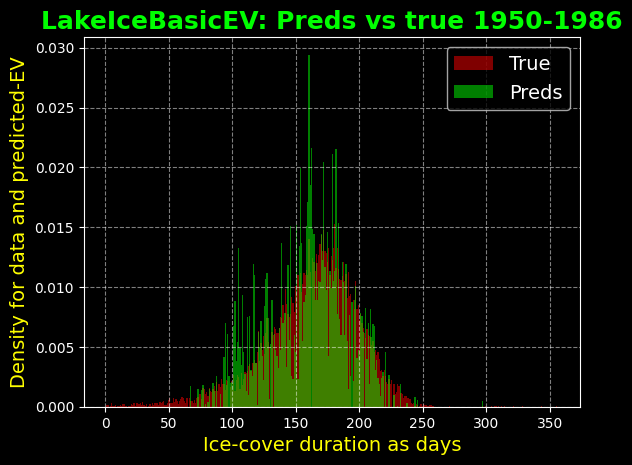

In [20]:
preds_vs_true_distribution(model_preds=first_half_preds,
                                true=first_half_y_numpy,
                                titles={'title':'LakeIceBasicEV: Preds vs true 1950-1986',
                                        'xlabel':'Ice-cover duration as days',
                                        'ylabel':'Density for data and predicted-EV'},
                                colors={'title':'lime',
                                        'xlabel':'yellow',
                                        'ylabel':'yellow',
                                        'preds':'lime',
                                        'true':'red'},
                                #file_path=visualization_path+'LakeIceBasicEV_preds_vs_true_1950-1986.png',
                                #file_path=None
                                )


In [21]:
first_half_probabilities, first_half_probability_table = LakeIceBasicEV_conditional_distributions(
                                                                                    predictions=first_half_preds,
                                                                                    min_value=0,
                                                                                    max_value=365,
                                                                                    return_probs=True)


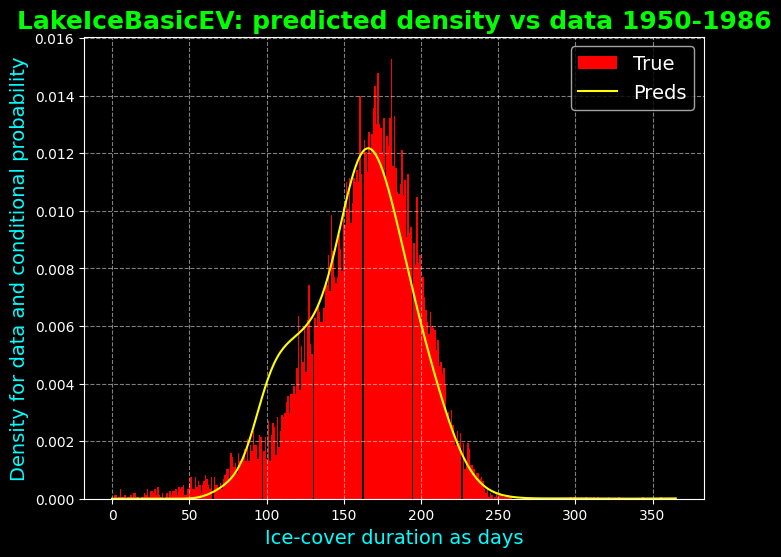

In [22]:
colors_lakeicebasicEV_1st = {'preds':'yellow','true':'red','title':'lime','xlabel':'cyan','ylabel':'cyan'}
titles_lakeicebasicEV_1st = {'title':'LakeIceBasicEV: predicted density vs data 1950-1986','xlabel':'Ice-cover duration as days','ylabel':'Density for data and conditional probability'}

visualize_densities(prediction_density=first_half_probability_table,
                    true_observations=first_half_y_numpy,
                    colors=colors_lakeicebasicEV_1st,
                    titles=titles_lakeicebasicEV_1st,
                    #return_fig=True,
                    #file_path=visualization_path+'LakeIceBasicEV_duration_cumulated_density_vs_data_1950-1986.png'
                    )

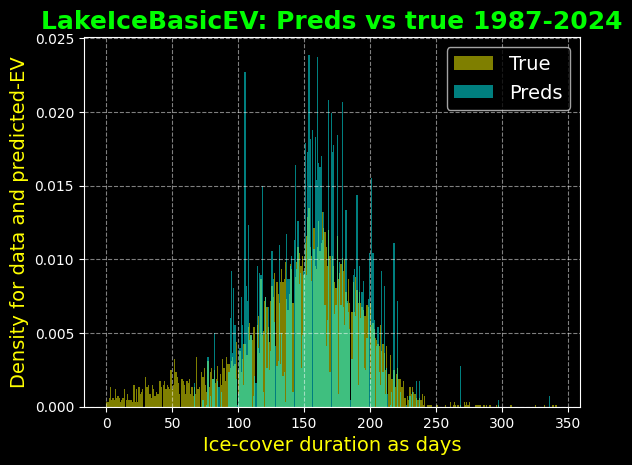

In [23]:
preds_vs_true_distribution(model_preds=second_half_preds,
                                true=second_half_y_numpy,
                                titles={'title':'LakeIceBasicEV: Preds vs true 1987-2024',
                                        'xlabel':'Ice-cover duration as days',
                                        'ylabel':'Density for data and predicted-EV'},
                                colors={'title':'lime',
                                        'xlabel':'yellow',
                                        'ylabel':'yellow',
                                        'preds':'cyan',
                                        'true':'yellow'},
                                #file_path=visualization_path+'LakeIceBasicEV_preds_vs_true_1987-2024.png',
                                #file_path=None
                                )

In [24]:
second_half_probabilities, second_half_probability_table = LakeIceBasicEV_conditional_distributions(
                                                                                    predictions=second_half_preds,
                                                                                    min_value=0,
                                                                                    max_value=365,
                                                                                    return_probs=True)

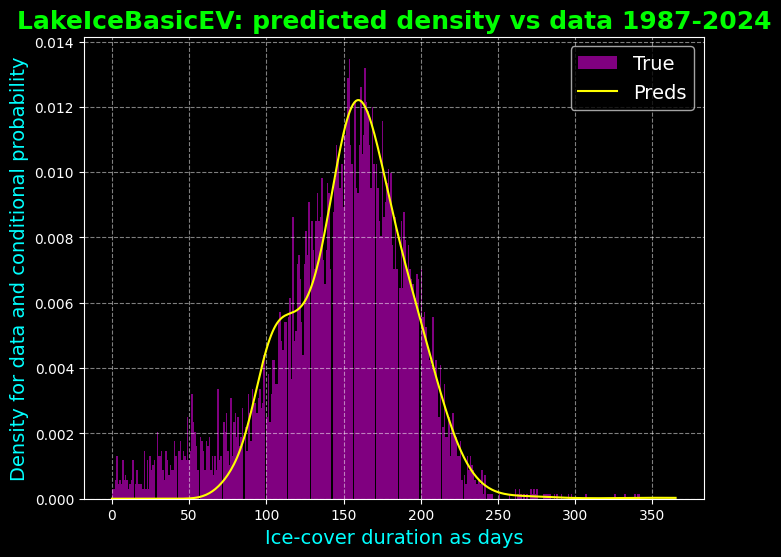

In [25]:
colors_lakeicebasicEV_2nd = {'preds':'yellow','true':'purple','title':'lime','xlabel':'cyan','ylabel':'cyan'}
titles_lakeicebasicEV_2nd = {'title':'LakeIceBasicEV: predicted density vs data 1987-2024','xlabel':'Ice-cover duration as days','ylabel':'Density for data and conditional probability'}

visualize_densities(prediction_density=second_half_probability_table,
                    true_observations=second_half_y_numpy,
                    colors=colors_lakeicebasicEV_2nd,
                    titles=titles_lakeicebasicEV_2nd,
                    #return_fig=True,
                    #file_path=visualization_path+'LakeIceBasicEV_duration_cumulated_density_vs_data_1987-2024.png'
                    )


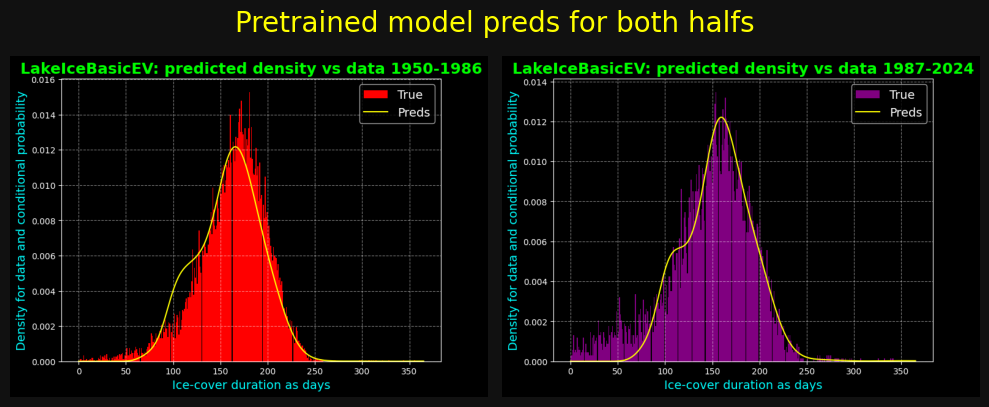

In [27]:
density_path_LakeIceBasicEV_19501986 = visualization_path+r'\LakeIceBasicEV_duration_cumulated_density_vs_data_1950-1986.png'
density_path_LakeIceBasicEV_19872024 = visualization_path+r'\LakeIceBasicEV_duration_cumulated_density_vs_data_1987-2024.png'

combine_plot_images(density_path=density_path_LakeIceBasicEV_19501986,
                    ev_path=density_path_LakeIceBasicEV_19872024,
                    title='Pretrained model preds for both halfs',
                    #file_path=visualization_path+'LakeIceBasicEV_pretrained_model_halves.png',
                    )

Visualization of distributions and predictions for splitted datasets. Third item of this visualization compares the predicted probability distribution between these datasets.

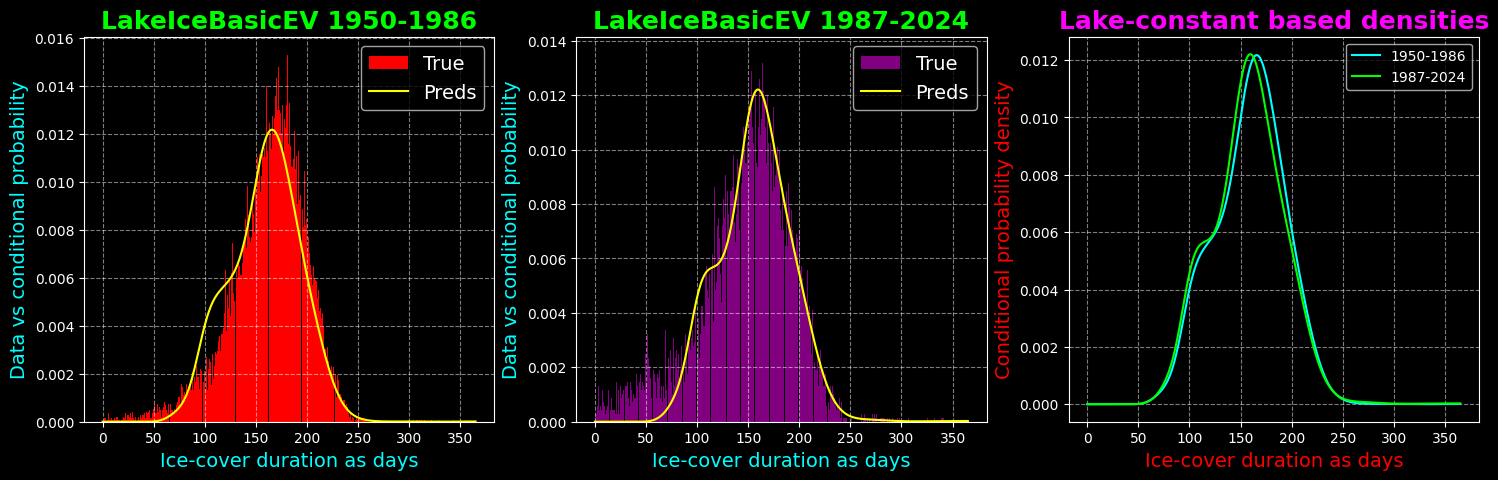

In [28]:
plt.style.use('dark_background')
fig = plt.figure(figsize=(18,5))

ax = fig.add_subplot(1,3,1)
plt.grid(linestyle='--',alpha=0.5)
plt.hist(first_half_y_numpy,
        bins=366,
        density=True,
        color='red',
        label='True')

plt.plot(first_half_probability_table,
             color='yellow',
             label='Preds')

plt.title('LakeIceBasicEV 1950-1986',
            fontsize=18,
            color='lime',
            fontweight='bold'
          )
plt.xlabel('Ice-cover duration as days',
        color='cyan',
                fontsize=14)
plt.ylabel('Data vs conditional probability',
        color='cyan',
        fontsize=14)
plt.legend(fontsize=14)

ax = fig.add_subplot(1,3,2)
plt.grid(linestyle='--',alpha=0.5)
plt.hist(second_half_y_numpy,
        bins=366,
        density=True,
        color='purple',
        label='True')

plt.plot(second_half_probability_table,
             color='yellow',
             label='Preds')

plt.title('LakeIceBasicEV 1987-2024',
            fontsize=18,
            color='lime',
            fontweight='bold'
          )
plt.xlabel('Ice-cover duration as days',
        color='cyan',
                fontsize=14)
plt.ylabel('Data vs conditional probability',
        color='cyan',
        fontsize=14)
plt.legend(fontsize=14)



ax = fig.add_subplot(1,3,3)
plt.grid(linestyle='--',alpha=0.5)
plt.plot(first_half_probability_table,label='1950-1986',color='cyan')
plt.plot(second_half_probability_table,label='1987-2024',color='lime')
plt.legend()
plt.xlabel('Ice-cover duration as days',color='red',fontsize=14)
plt.ylabel('Conditional probability density', color='red',fontsize=14)
plt.title('Lake-constant based densities',color='magenta',fontsize=18, fontweight = 'bold')
#plt.savefig(visualization_path+'LakeIceBasicEV_density_comparison_for_halves.png',bbox_inches='tight')
plt.show()

According to this model, there is over 2 day difference in expected ice-cover duration, when we use only lake-constants as data. Good to notice that some lakes might be included only or mostly in other dataset.

In [29]:
day_vector = np.arange(0,366)

In [30]:
first_half_probability_table.to_numpy().squeeze() @ day_vector

158.8307444443696

In [31]:
second_half_probability_table.to_numpy().squeeze() @ day_vector

156.39389372411173

In [32]:
first_half_stations = set(df_ice_clean_sorted.iloc[:split_index,:].station_id.values)
second_half_stations = set(df_ice_clean_sorted.iloc[split_index:,:].station_id.values)
just_in_first_half =first_half_stations-second_half_stations
just_in_second_half = second_half_stations.difference(first_half_stations)
union_of_stations = first_half_stations.intersection(second_half_stations)

* The amount of stations in first half is 689 and second half includes 468 stations.
* Significant proportion of stations in second half are also included in the first half.
    * The amount of stations just in first half: 276
    * The amount of stations just in second half: 55
    * The amount of stations in both halves: 413


In [33]:
len(first_half_stations),len(second_half_stations),len(just_in_first_half),len(just_in_second_half),len(union_of_stations)

(689, 468, 276, 55, 413)

In [34]:
55/468

0.11752136752136752

## Captum analysis for feature importances
* Captum is a network analysis package for PyTorch based networks.
* As PyTorch itself, this library is also a product of Facebook / Meta (or an organization linked to Facebook / Meta).
* We use integrated gradients method to analyze feature attributions for predicted values. For further information about this method, you can find the original paper here https://proceedings.mlr.press/v70/sundararajan17a.html

In [35]:
pretrained_model

LakeIceBasicEV(
  (model): Sequential(
    (0): Linear(in_features=10, out_features=128, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): LeakyReLU(negative_slope=0.2)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): LeakyReLU(negative_slope=0.2)
    (6): Linear(in_features=32, out_features=16, bias=True)
    (7): LeakyReLU(negative_slope=0.2)
    (8): Linear(in_features=16, out_features=1, bias=True)
    (9): ReLU()
  )
)

In [36]:
from captum.attr import IntegratedGradients
from scipy import stats

In [37]:
ig = IntegratedGradients(pretrained_model)

In [38]:
inputs_for_ig = duration_dataset_sorted.duration_table[:,:-1].detach().clone()
inputs_for_ig.requires_grad_() #in-place operation

tensor([[0.0000, 0.0000, 0.0000,  ..., 0.2880, 0.5086, 0.0285],
        [0.0000, 0.0000, 0.0000,  ..., 0.2944, 0.4750, 0.1158],
        [0.0000, 0.0000, 0.0000,  ..., 0.2979, 0.4966, 0.0571],
        ...,
        [0.0000, 1.0000, 0.0000,  ..., 0.0628, 0.5786, 0.0995],
        [0.0000, 1.0000, 0.0000,  ..., 0.3105, 0.5649, 0.0914],
        [0.0000, 0.0000, 0.0000,  ..., 0.1697, 0.3508, 0.0052]],
       device='cuda:0', requires_grad=True)

In [39]:
attr, delta = ig.attribute(inputs_for_ig, return_convergence_delta=True)
attr = attr.cpu().detach().numpy()

In [40]:
#ig.attribute?

In [41]:
def visualize_importances(feature_columns,
                          importances,
                          title='Average feature importances',
                          plot=True,
                          xlabel='Features',
                          ylabel='Average impact to results',
                          file_path=None):
    print(title)
    for i in range(len(feature_columns)):
        print(f'{feature_columns[i]} : {importances[i]:.4f}')
    x_positions = (np.arange(len(feature_columns)))
    if plot:
        
        fig = plt.figure(figsize=(12,6))
        plt.grid(linestyle='--',alpha=0.5)
        plt.bar(x_positions,importances,color='lime')
        plt.xticks(x_positions,feature_columns,color='cyan',fontsize=14,rotation=90,ha='right')
        plt.xlabel(xlabel,fontsize=20,color='yellow')
        plt.ylabel(ylabel,fontsize=20,color='yellow')
        plt.title(title,color='yellow',fontsize=22)
        if file_path is not None:
            plt.savefig(file_path,bbox_inches='tight')
    else:
        return fig
    

LakeIceBasicEV avg feature attribution based on integrated gradients
CA : 5.6018
FI : -5.8534
NO : -1.1294
SE : -21.7712
US : 2.1218
lat_wgs84 : 111.6948
lon_wgs84 : 68.1921
altitude_m : 10.7476
log_area_ha : -5.2277
depth_max_m : -6.2288


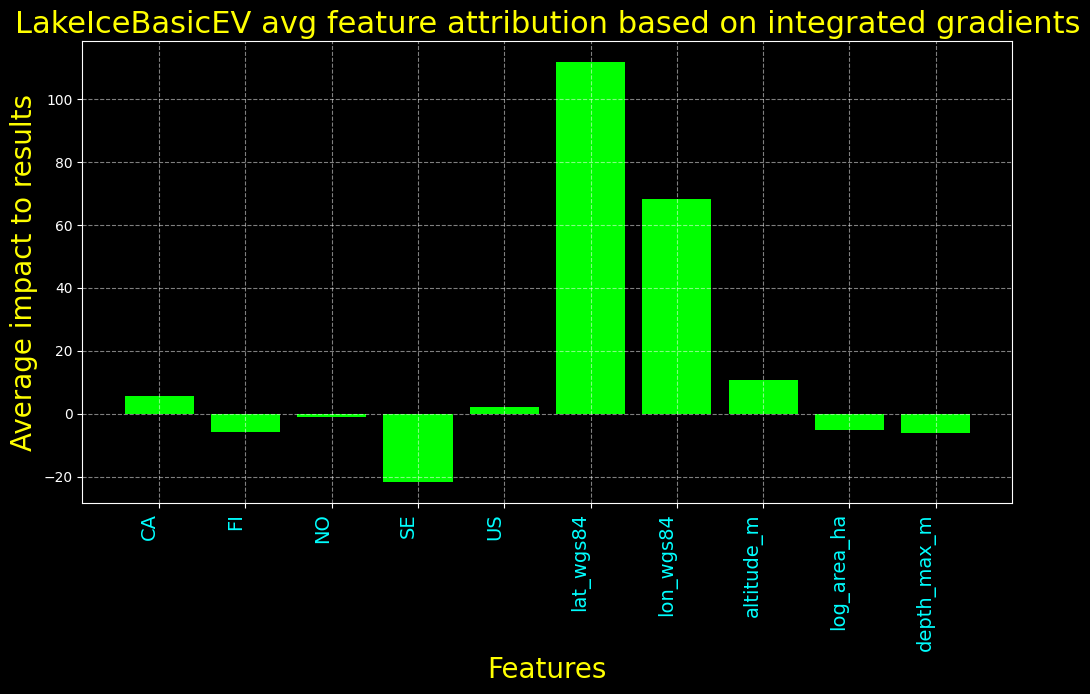

In [42]:
visualize_importances(feature_columns=[x[0] for x in df_duration_sorted.columns.values[:-1]],
                      importances=np.mean(attr,axis=0),
                      title='LakeIceBasicEV avg feature attribution based on integrated gradients',
                      #file_path=visualization_path+'LakeIceBasicEV_feature_importances.png'
                      )

In [43]:
model_data_numpy = inputs_for_ig.cpu().detach().numpy()

In [44]:
model_data_numpy.shape

(22279, 10)

# Large visualization of feature attributions
* Notice that this model considers almost perfect linear connection between the value of lat_wgs84 and it's average attribution. The higher latitude the more it effects to results. As expected, the location features had the highest impact on predictions.
* For the less important features attribution is nonlinearly connected to prediction.
* Notice that we country indicators in our model, so it makes sense that value 0 does not contribute to the final prediction.
* In scatterplots the circle size represents the amount of observations for each bin of values.

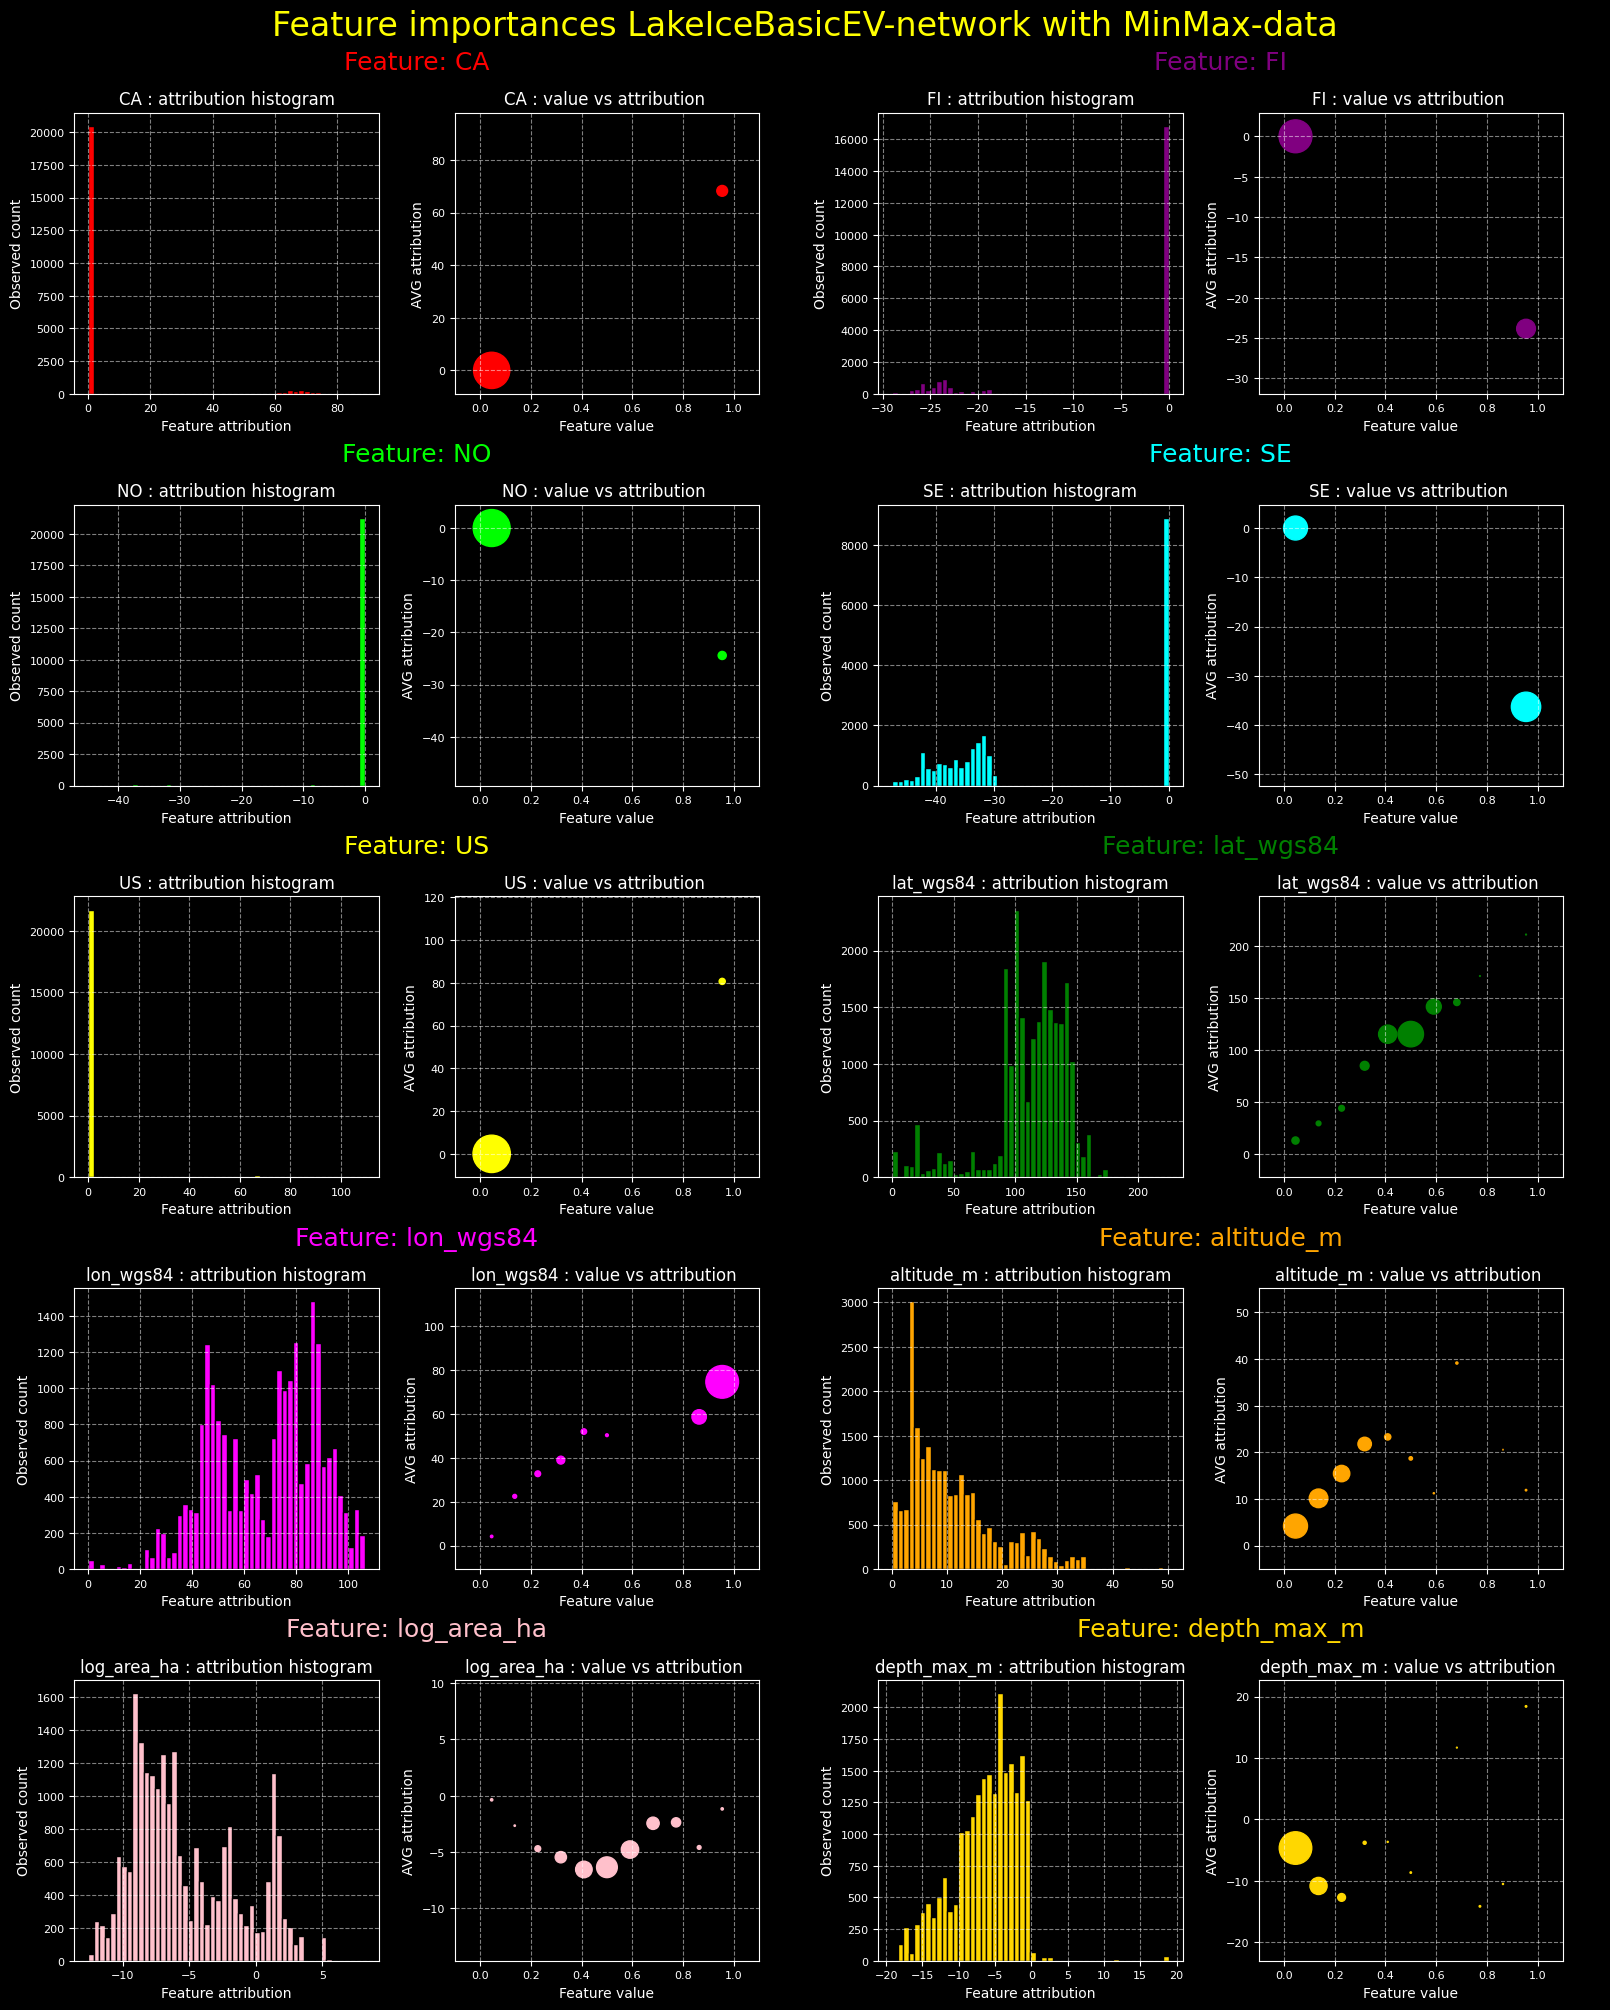

In [45]:
colors = ['red','purple','lime','cyan','yellow','green','magenta','orange','pink','gold']
feature_columns = [x[0] for x in df_duration_sorted.columns.values[:-1]]
n_columns = attr.shape[1]
n_rows = (attr.shape[1]+1)//2

fig , outer_axes = plt.subplots(nrows=n_rows,ncols=2,figsize=(16,4*n_rows),layout='constrained')
outer_axes = outer_axes.flatten()
for i, col in enumerate(feature_columns):

    inner_ax_left = outer_axes[i].inset_axes([0.05,0.1,0.4,0.8])
    inner_ax_right = outer_axes[i].inset_axes([0.55,0.1,0.4,0.8])
    inner_ax_left.grid(linestyle='--',alpha=0.5)
    inner_ax_left.hist(attr[:,i],bins=50,color=colors[i],edgecolor='black',label=f'{col} hist')
    inner_ax_left.set_title(f'{feature_columns[i]} : attribution histogram')
    inner_ax_left.tick_params(axis='both',which='major',labelsize=8)
    inner_ax_left.set_xlabel('Feature attribution')
    inner_ax_left.set_ylabel('Observed count')

    bin_means, bin_edges, _ = stats.binned_statistic(model_data_numpy[:,i], attr[:,i], statistic='mean', bins=11)
    bin_count, _, _ = stats.binned_statistic(model_data_numpy[:,i], attr[:,i], statistic='count', bins=11)
    bin_width = (bin_edges[1] - bin_edges[0])
    bin_centers = bin_edges[1:] - bin_width/2

    max_attr = np.max(attr[:,i])
    min_attr = np.min(attr[:,i])
    scale_corrections = (max_attr - min_attr) * 0.1
    inner_ax_right.grid(linestyle='--',alpha=0.5)
    inner_ax_right.scatter(bin_centers,
                           bin_means,
                           s=bin_count/30,
                           label=f'{col} attr',
                           color=colors[i])
    inner_ax_right.set_title(f'{feature_columns[i]} : value vs attribution ')
    inner_ax_right.tick_params(axis='both',which='major',labelsize=8)
    inner_ax_right.set_xlim((-0.1,1.1))
    inner_ax_right.set_ylim((min_attr-scale_corrections,max_attr+scale_corrections))
    inner_ax_right.set_xlabel('Feature value')
    inner_ax_right.set_ylabel('AVG attribution')
    outer_axes[i].set_title(f'Feature: {col}', fontsize=18,color=colors[i])
    outer_axes[i].axis('off')

fig.suptitle('Feature importances LakeIceBasicEV-network with MinMax-data',color='yellow',fontsize=24)
#plt.savefig(visualization_path+'LakeIceBasic_feature_importances_large.png',bbox_inches='tight')
plt.show()
    